## # Import necessary libraries

In [33]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings  
warnings.filterwarnings('ignore') 
from sklearn.preprocessing import StandardScaler, MinMaxScaler  
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV,cross_validate  #  
import shap

# Data Preprocessing

# Train Test Split

In [3]:
df=pd.read_csv("BRFSS2023_Cleaned.csv")

In [4]:
df.head()

,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivity,HadHeartAttack,HadStroke,HadAsthma,HadSkinCancer,...,EverHadPneumoniaVax,ReceivedFluVax,EverTestedHIV,EverHadCOVID,AgeGroup,HighBloodPressureRisk,CholesterolChecked,BMICategory,SmokingStatus,DrinksPerDay
0,Female,Very good,NaN,NaN,Within past 2 years,No,No,No,No,No,...,No,No,No,No,80+,No,Yes,Obese,Never smoked,0.0
1,Female,Very good,NaN,NaN,Within past 2 years,Yes,No,No,No,No,...,Yes,Yes,No,No,80+,No,Yes,Overweight,Never smoked,0.0
2,Female,Fair,6.0,2.0,Within past year,Yes,No,No,Yes,No,...,Yes,Yes,No,No,80+,No,Yes,Normal,Former smoker,0.0
3,Female,Very good,2.0,NaN,Within past 5 years,Yes,No,No,No,Yes,...,Yes,Yes,Yes,No,75-79,Yes,Yes,Overweight,Never smoked,0.0
4,Female,Fair,NaN,NaN,Within past year,Yes,No,No,No,No,...,Yes,No,No,No,75-79,No,Yes,Overweight,Never smoked,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412430 entries, 0 to 412429
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Sex                        412430 non-null  object 
 1   GeneralHealth              411237 non-null  object 
 2   PhysicalHealthDays         155381 non-null  float64
 3   MentalHealthDays           158755 non-null  float64
 4   LastCheckupTime            406832 non-null  object 
 5   PhysicalActivity           411264 non-null  object 
 6   HadHeartAttack             412430 non-null  object 
 7   HadStroke                  411356 non-null  object 
 8   HadAsthma                  411009 non-null  object 
 9   HadSkinCancer              409825 non-null  object 
 10  HadOtherCancer             410382 non-null  object 
 11  HadCOPD                    410689 non-null  object 
 12  HadDepressiveDisorder      410136 non-null  object 
 13  HadKidneyDisease           41

In [6]:
X = df.drop("HadHeartAttack", axis=1)
y = df["HadHeartAttack"]
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
total=len(df)
print("\nDataset distribution:")
print(f"Train: {len(X_train)/total:.2%}")
print(f"Validation: {len(X_val)/total:.2%}")
print(f"Test: {len(X_test)/total:.2%}")
print("\nTarget distribution:")
print("Train:")
print(y_train.value_counts(normalize=True))
print("\nValidation:")
print(y_val.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Training: (329944, 31) (329944,)
Validation: (41243, 31) (41243,)
Test: (41243, 31) (41243,)

Dataset distribution:
Train: 80.00%
Validation: 10.00%
Test: 10.00%

Target distribution:
Train:
HadHeartAttack
No     0.943269
Yes    0.056731
Name: proportion, dtype: float64

Validation:
HadHeartAttack
No     0.943263
Yes    0.056737
Name: proportion, dtype: float64

Test:
HadHeartAttack
No     0.943263
Yes    0.056737
Name: proportion, dtype: float64


In [7]:
# ======================================================
# COUNT YES AND NO IN EACH SPLIT
# ======================================================

print("Target counts in each dataset")
print("="*50)

print("\nTraining set:")
print(y_train.value_counts())
print("Percentage:")
print(y_train.value_counts(normalize=True)*100)


print("\nValidation set:")
print(y_val.value_counts())
print("Percentage:")
print(y_val.value_counts(normalize=True)*100)


print("\nTest set:")
print(y_test.value_counts())
print("Percentage:")
print(y_test.value_counts(normalize=True)*100)

Target counts in each dataset

Training set:
HadHeartAttack
No     311226
Yes     18718
Name: count, dtype: int64
Percentage:
HadHeartAttack
No     94.326916
Yes     5.673084
Name: proportion, dtype: float64

Validation set:
HadHeartAttack
No     38903
Yes     2340
Name: count, dtype: int64
Percentage:
HadHeartAttack
No     94.32631
Yes     5.67369
Name: proportion, dtype: float64

Test set:
HadHeartAttack
No     38903
Yes     2340
Name: count, dtype: int64
Percentage:
HadHeartAttack
No     94.32631
Yes     5.67369
Name: proportion, dtype: float64


In [8]:
X_test

,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivity,HadStroke,HadAsthma,HadSkinCancer,HadOtherCancer,...,EverHadPneumoniaVax,ReceivedFluVax,EverTestedHIV,EverHadCOVID,AgeGroup,HighBloodPressureRisk,CholesterolChecked,BMICategory,SmokingStatus,DrinksPerDay
113017,Male,Very good,5.0,NaN,Within past year,Yes,No,No,No,No,...,No,Yes,No,Yes,65-69,No,Yes,Normal,Never smoked,29.0
139729,Female,Good,NaN,NaN,Within past year,No,No,No,No,No,...,Yes,Yes,No,No,75-79,No,Yes,Obese,Never smoked,0.0
84112,Female,Excellent,NaN,NaN,NaN,Yes,No,No,No,No,...,NaN,Yes,No,Yes,25-29,Yes,Never had cholesterol checked,Normal,Never smoked,NaN
291915,Female,Excellent,NaN,30.0,Within past year,Yes,No,No,No,No,...,No,No,No,No,25-29,Yes,Yes,Normal,Never smoked,3.0
66976,Female,Excellent,2.0,2.0,Within past year,Yes,No,No,No,No,...,No,No,Yes,No,50-54,Yes,Yes,Normal,Former smoker,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71758,Female,Very good,NaN,NaN,Within past year,No,No,No,No,No,...,No,No,NaN,No,80+,No,Yes,Normal,Former smoker,43.0
181026,Female,Very good,NaN,4.0,Within past year,Yes,No,No,No,No,...,Yes,Yes,Yes,No,35-39,Yes,Yes,Overweight,Never smoked,27.0
237179,Female,Poor,15.0,20.0,Within past year,Yes,No,No,No,No,...,No,No,Yes,Yes,40-44,Yes,NaN,Obese,Current smoker - daily,0.0
215411,Female,Poor,30.0,NaN,Within past year,Yes,No,No,Yes,Yes,...,No,Yes,No,No,70-74,No,Yes,Normal,Former smoker,3.0


In [9]:
X_train

,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivity,HadStroke,HadAsthma,HadSkinCancer,HadOtherCancer,...,EverHadPneumoniaVax,ReceivedFluVax,EverTestedHIV,EverHadCOVID,AgeGroup,HighBloodPressureRisk,CholesterolChecked,BMICategory,SmokingStatus,DrinksPerDay
130053,Female,Good,NaN,NaN,Within past year,Yes,No,No,No,No,...,Yes,Yes,Yes,Yes,50-54,Yes,Yes,Obese,Never smoked,0.0
296406,Female,Good,NaN,NaN,NaN,Yes,No,No,No,No,...,No,No,No,No,35-39,Yes,NaN,Obese,Current smoker - daily,100.0
238390,Female,Fair,2.0,5.0,Within past year,Yes,No,No,No,No,...,No,No,No,No,50-54,No,Yes,Overweight,Current smoker - daily,67.0
128718,Male,Very good,NaN,NaN,Within past year,Yes,No,No,No,No,...,No,No,No,Yes,60-64,No,Yes,Obese,Never smoked,29.0
146977,Male,Very good,NaN,NaN,Within past year,Yes,No,No,No,No,...,Yes,No,Yes,No,70-74,No,Yes,Overweight,Former smoker,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161292,Female,Good,30.0,NaN,Within past year,No,No,No,No,No,...,No,No,No,Yes,60-64,No,Yes,Obese,Current smoker - daily,10.0
203828,Male,Good,NaN,NaN,NaN,No,No,No,No,No,...,No,Yes,No,No,50-54,Yes,NaN,Normal,Never smoked,0.0
165606,Female,Good,NaN,2.0,Within past year,Yes,No,Yes,No,No,...,No,No,Yes,Yes,40-44,No,Yes,Obese,Never smoked,0.0
231399,Female,Good,NaN,NaN,Within past year,No,No,No,Yes,No,...,Yes,No,No,No,65-69,No,Yes,Obese,Former smoker,0.0


In [10]:
y_train

130053     No
296406     No
238390     No
128718     No
146977     No
         ... 
161292     No
203828     No
165606     No
231399    Yes
308994     No
Name: HadHeartAttack, Length: 329944, dtype: object

In [11]:
X_test

,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivity,HadStroke,HadAsthma,HadSkinCancer,HadOtherCancer,...,EverHadPneumoniaVax,ReceivedFluVax,EverTestedHIV,EverHadCOVID,AgeGroup,HighBloodPressureRisk,CholesterolChecked,BMICategory,SmokingStatus,DrinksPerDay
113017,Male,Very good,5.0,NaN,Within past year,Yes,No,No,No,No,...,No,Yes,No,Yes,65-69,No,Yes,Normal,Never smoked,29.0
139729,Female,Good,NaN,NaN,Within past year,No,No,No,No,No,...,Yes,Yes,No,No,75-79,No,Yes,Obese,Never smoked,0.0
84112,Female,Excellent,NaN,NaN,NaN,Yes,No,No,No,No,...,NaN,Yes,No,Yes,25-29,Yes,Never had cholesterol checked,Normal,Never smoked,NaN
291915,Female,Excellent,NaN,30.0,Within past year,Yes,No,No,No,No,...,No,No,No,No,25-29,Yes,Yes,Normal,Never smoked,3.0
66976,Female,Excellent,2.0,2.0,Within past year,Yes,No,No,No,No,...,No,No,Yes,No,50-54,Yes,Yes,Normal,Former smoker,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71758,Female,Very good,NaN,NaN,Within past year,No,No,No,No,No,...,No,No,NaN,No,80+,No,Yes,Normal,Former smoker,43.0
181026,Female,Very good,NaN,4.0,Within past year,Yes,No,No,No,No,...,Yes,Yes,Yes,No,35-39,Yes,Yes,Overweight,Never smoked,27.0
237179,Female,Poor,15.0,20.0,Within past year,Yes,No,No,No,No,...,No,No,Yes,Yes,40-44,Yes,NaN,Obese,Current smoker - daily,0.0
215411,Female,Poor,30.0,NaN,Within past year,Yes,No,No,Yes,Yes,...,No,Yes,No,No,70-74,No,Yes,Normal,Former smoker,3.0


In [13]:
y_test

113017    No
139729    No
84112     No
291915    No
66976     No
          ..
71758     No
181026    No
237179    No
215411    No
300266    No
Name: HadHeartAttack, Length: 41243, dtype: object

In [12]:
train_df = pd.concat([X_train, y_train], axis=1)
val_df = pd.concat([X_val, y_val], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)
train_df.to_csv('train_data.csv', index=False)
val_df.to_csv('validation_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)
print("Datasets saved successfully.")

Datasets saved successfully.


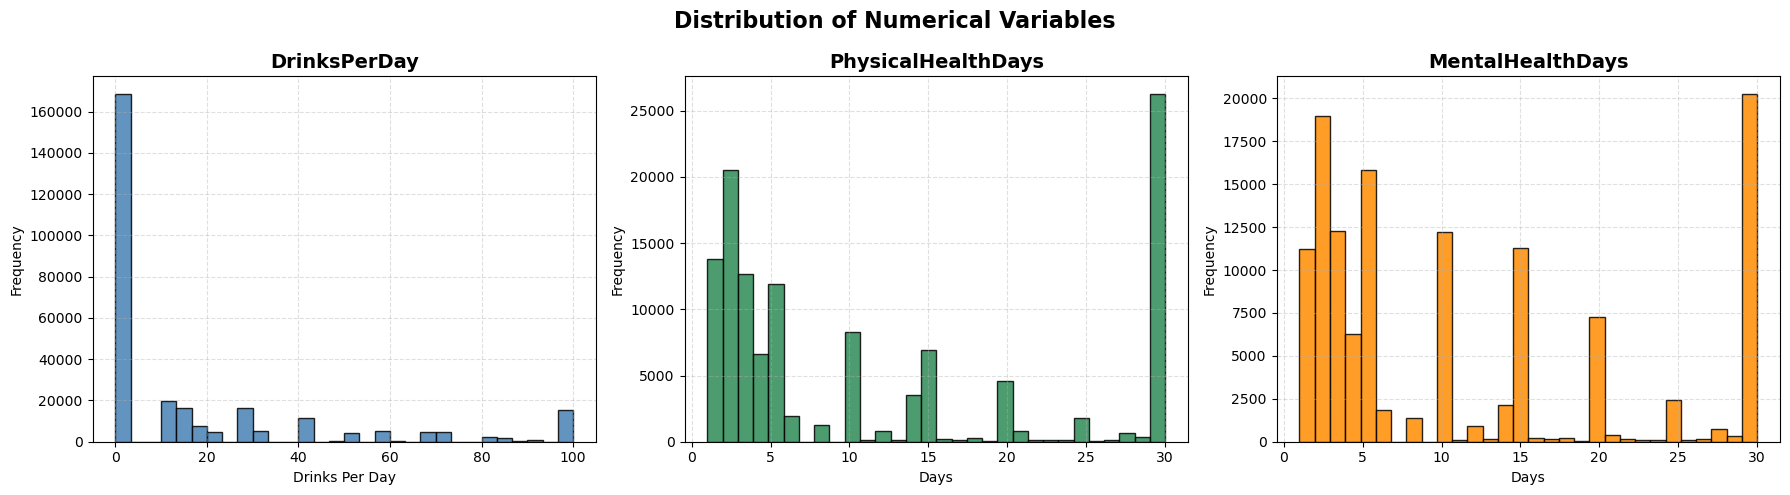

In [13]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(
    X_train['DrinksPerDay'],
    bins=30,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)
axes[0].set_title('DrinksPerDay', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Drinks Per Day')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].hist(
    X_train['PhysicalHealthDays'],
    bins=30,
    color='seagreen',
    edgecolor='black',
    alpha=0.85
)
axes[1].set_title('PhysicalHealthDays', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, linestyle='--', alpha=0.4)


axes[2].hist(
    X_train['MentalHealthDays'],
    bins=30,
    color='darkorange',
    edgecolor='black',
    alpha=0.85
)
axes[2].set_title('MentalHealthDays', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Days')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.suptitle(
    'Distribution of Numerical Variables',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'Numerical_Variables_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Outlier Detection and Treatement

The interquartile range (IQR) method was applied to detect potential outliers in DrinksPerDay, PhysicalHealthDays, and MentalHealthDays using the training dataset. The computed thresholds indicated no observations outside the defined bounds, resulting in 0% identified outliers for all variables. However, the derived thresholds for PhysicalHealthDays and MentalHealthDays extended beyond their valid survey range (0–30 days), highlighting the limitation of applying purely statistical outlier detection to bounded BRFSS variables. This indicates that extreme values in these variables are valid survey responses rather than erroneous data, and therefore no capping was applied

IQR OUTLIER DETECTION (TRAINING SET)

PhysicalHealthDays
Q1               : 2.00
Q3               : 20.00
IQR              : 18.00
Lower Threshold  : -25.00
Upper Threshold  : 47.00
Outliers         : 0
Percentage       : 0.000%

MentalHealthDays
Q1               : 3.00
Q3               : 20.00
IQR              : 17.00
Lower Threshold  : -22.50
Upper Threshold  : 45.50
Outliers         : 0
Percentage       : 0.000%

DrinksPerDay
Q1               : 0.00
Q3               : 27.00
IQR              : 27.00
Lower Threshold  : -40.50
Upper Threshold  : 67.50
Outliers         : 25501
Percentage       : 7.729%

Summary
             Variable   Q1    Q3   IQR  Lower Threshold  Upper Threshold
0  PhysicalHealthDays  2.0  20.0  18.0            -25.0             47.0
1    MentalHealthDays  3.0  20.0  17.0            -22.5             45.5
2        DrinksPerDay  0.0  27.0  27.0            -40.5             67.5


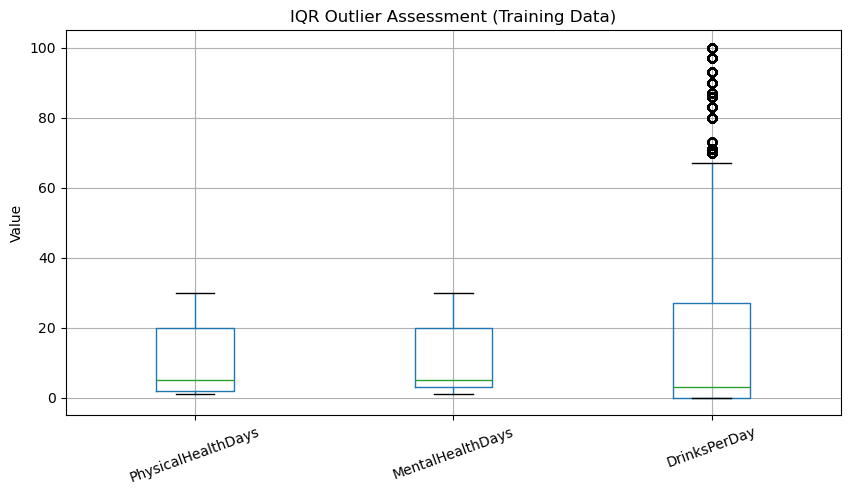

In [14]:
continuous_cols = [
    "PhysicalHealthDays",
    "MentalHealthDays",
    "DrinksPerDay"
]
results = []

print("="*70)
print("IQR OUTLIER DETECTION (TRAINING SET)")
print("="*70)

for col in continuous_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (X_train[col] < lower) | (X_train[col] > upper)

    n_outliers = mask.sum()
    pct_outliers = (n_outliers / len(X_train)) * 100

    results.append({
        "Variable": col,
        "Q1": round(Q1,2),
        "Q3": round(Q3,2),
        "IQR": round(IQR,2),
        "Lower Threshold": round(lower,2),
        "Upper Threshold": round(upper,2),

    })

    print(f"\n{col}")
    print(f"Q1               : {Q1:.2f}")
    print(f"Q3               : {Q3:.2f}")
    print(f"IQR              : {IQR:.2f}")
    print(f"Lower Threshold  : {lower:.2f}")
    print(f"Upper Threshold  : {upper:.2f}")
    print(f"Outliers         : {n_outliers}")
    print(f"Percentage       : {pct_outliers:.3f}%")

summary = pd.DataFrame(results)

print("\nSummary")
print(summary)

summary.to_csv("IQR_Outlier_Summary.csv", index=False)

# ==========================================
# BOXPLOTS (TRAINING DATA ONLY)
# ==========================================

plt.figure(figsize=(10,5))

X_train[continuous_cols].boxplot()

plt.title("IQR Outlier Assessment (Training Data)")
plt.ylabel("Value")
plt.xticks(rotation=20)

plt.show()

In [15]:
numerical_features = [
    "PhysicalHealthDays",
    "MentalHealthDays",
    "DrinksPerDay"
]

print("=" * 70)
print("NUMERICAL FEATURES BEFORE PREPROCESSING")
print("=" * 70)

summary = []

for col in numerical_features:
    print(f"\n{col}")
    print("-" * 50)

    summary.append({
        "Variable": col,
        "Minimum": df[col].min(),
        "Maximum": df[col].max(),
        "Unique Values": df[col].nunique()
    })

summary_df = pd.DataFrame(summary)

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(summary_df)

NUMERICAL FEATURES BEFORE PREPROCESSING

PhysicalHealthDays
--------------------------------------------------

MentalHealthDays
--------------------------------------------------

DrinksPerDay
--------------------------------------------------

SUMMARY
             Variable  Minimum  Maximum  Unique Values
0  PhysicalHealthDays      1.0     30.0             28
1    MentalHealthDays      1.0     30.0             28
2        DrinksPerDay      0.0    100.0             33


## Check and treat Missing Value

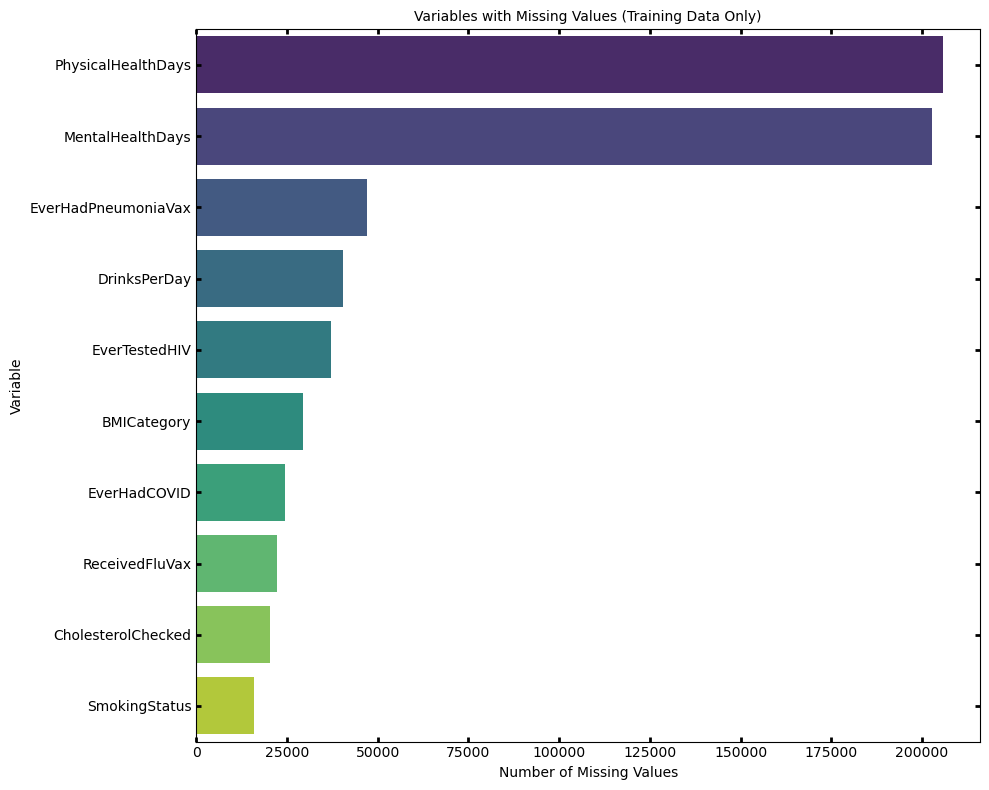

Training data columns:
Index(['Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays',
       'LastCheckupTime', 'PhysicalActivity', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadOtherCancer', 'HadCOPD', 'HadDepressiveDisorder',
       'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DifficultyHearing',
       'DifficultySeeing', 'DifficultyMakingDecisions', 'DifficultyWalking',
       'DifficultyDressing', 'DifficultyErrands', 'EverHadPneumoniaVax',
       'ReceivedFluVax', 'EverTestedHIV', 'EverHadCOVID', 'AgeGroup',
       'HighBloodPressureRisk', 'CholesterolChecked', 'BMICategory',
       'SmokingStatus', 'DrinksPerDay'],
      dtype='object')

Missing values in training data:
                           Missing Values  Missing Percentage Data Type
PhysicalHealthDays                 205679           62.337548   float64
MentalHealthDays                   202608           61.406784   float64
EverHadPneumoniaVax                 47037           14.256056    object
D

In [16]:
structure_data = pd.DataFrame({
    'Missing Values': X_train.isna().sum(),
    'Missing Percentage': (X_train.isna().sum() / len(X_train)) * 100,
    'Data Type': X_train.dtypes
}).sort_values(
    by='Missing Values',
    ascending=False
)

missing_data = structure_data[
    structure_data['Missing Values'] > 0
]

plt.figure(figsize=(10, 8))

sns.barplot(
    y=missing_data.index[:10],
    x=missing_data['Missing Values'][:10],
    palette="viridis"
)


plt.tick_params(
    axis='both',
    which='both',
    direction='in',
    top=True,
    right=True,
    labelsize=10,
    width=2
)


plt.title(
    "Variables with Missing Values (Training Data Only)",
    fontsize=10
)

plt.xlabel(
    "Number of Missing Values",
    fontsize=10
)

plt.ylabel(
    "Variable",
    fontsize=10
)

plt.tight_layout()
plt.show()


# ======================================================
# Display Missing Values Table
# ======================================================

print("Training data columns:")
print(X_train.columns)

print("\nMissing values in training data:")
print(structure_data)

In [17]:
def missing_summary(df, name):

    total_missing = df.isnull().sum().sum()

    total_entries = df.size

    missing_percentage = (
        total_missing / total_entries
    ) * 100


    print("="*60)
    print(name)
    print("="*60)

    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]:,}")
    print(f"Total entries: {total_entries:,}")
    print(f"Total missing values: {total_missing:,}")
    print(f"Missing percentage: {missing_percentage:.2f}%")

missing_summary(
    X_train,
    "Training Set"
)

missing_summary(
    X_val,
    "Validation Set"
)

missing_summary(
    X_test,
    "Test Set"
)

Training Set
Rows: 329,944
Columns: 31
Total entries: 10,228,264
Total missing values: 739,648
Missing percentage: 7.23%
Validation Set
Rows: 41,243
Columns: 31
Total entries: 1,278,533
Total missing values: 92,313
Missing percentage: 7.22%
Test Set
Rows: 41,243
Columns: 31
Total entries: 1,278,533
Total missing values: 92,874
Missing percentage: 7.26%


# IMPUTATION

In [20]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

if numeric_cols:

    numeric_imputer = SimpleImputer(strategy='median')

    X_train[numeric_cols] = numeric_imputer.fit_transform(
        X_train[numeric_cols]
    )

    X_val[numeric_cols] = numeric_imputer.transform(
        X_val[numeric_cols]
    )

    X_test[numeric_cols] = numeric_imputer.transform(
        X_test[numeric_cols]
    )


if categorical_cols:

    categorical_imputer = SimpleImputer(strategy='most_frequent')

    X_train[categorical_cols] = categorical_imputer.fit_transform(
        X_train[categorical_cols]
    )

    X_val[categorical_cols] = categorical_imputer.transform(
        X_val[categorical_cols]
    )

    X_test[categorical_cols] = categorical_imputer.transform(
        X_test[categorical_cols]
    )
print("✅ Imputation complete")

print("\nRemaining NaN values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

X_train.to_csv("X_train_imputed.csv", index=False)
X_val.to_csv("X_val_imputed.csv", index=False)
X_test.to_csv("X_test_imputed.csv", index=False)

print("\nFiles saved successfully.")

✅ Imputation complete

Remaining NaN values:
Train: 0
Validation: 0
Test: 0

Files saved successfully.


## Visualization of Qualitative and Quantitative Datasets

In [21]:
cat= df.select_dtypes('object').drop('HadHeartAttack',axis = 1)
num= df.select_dtypes('number')

Categorical Features: 7
Binary Features: 21
Numerical Features: 3


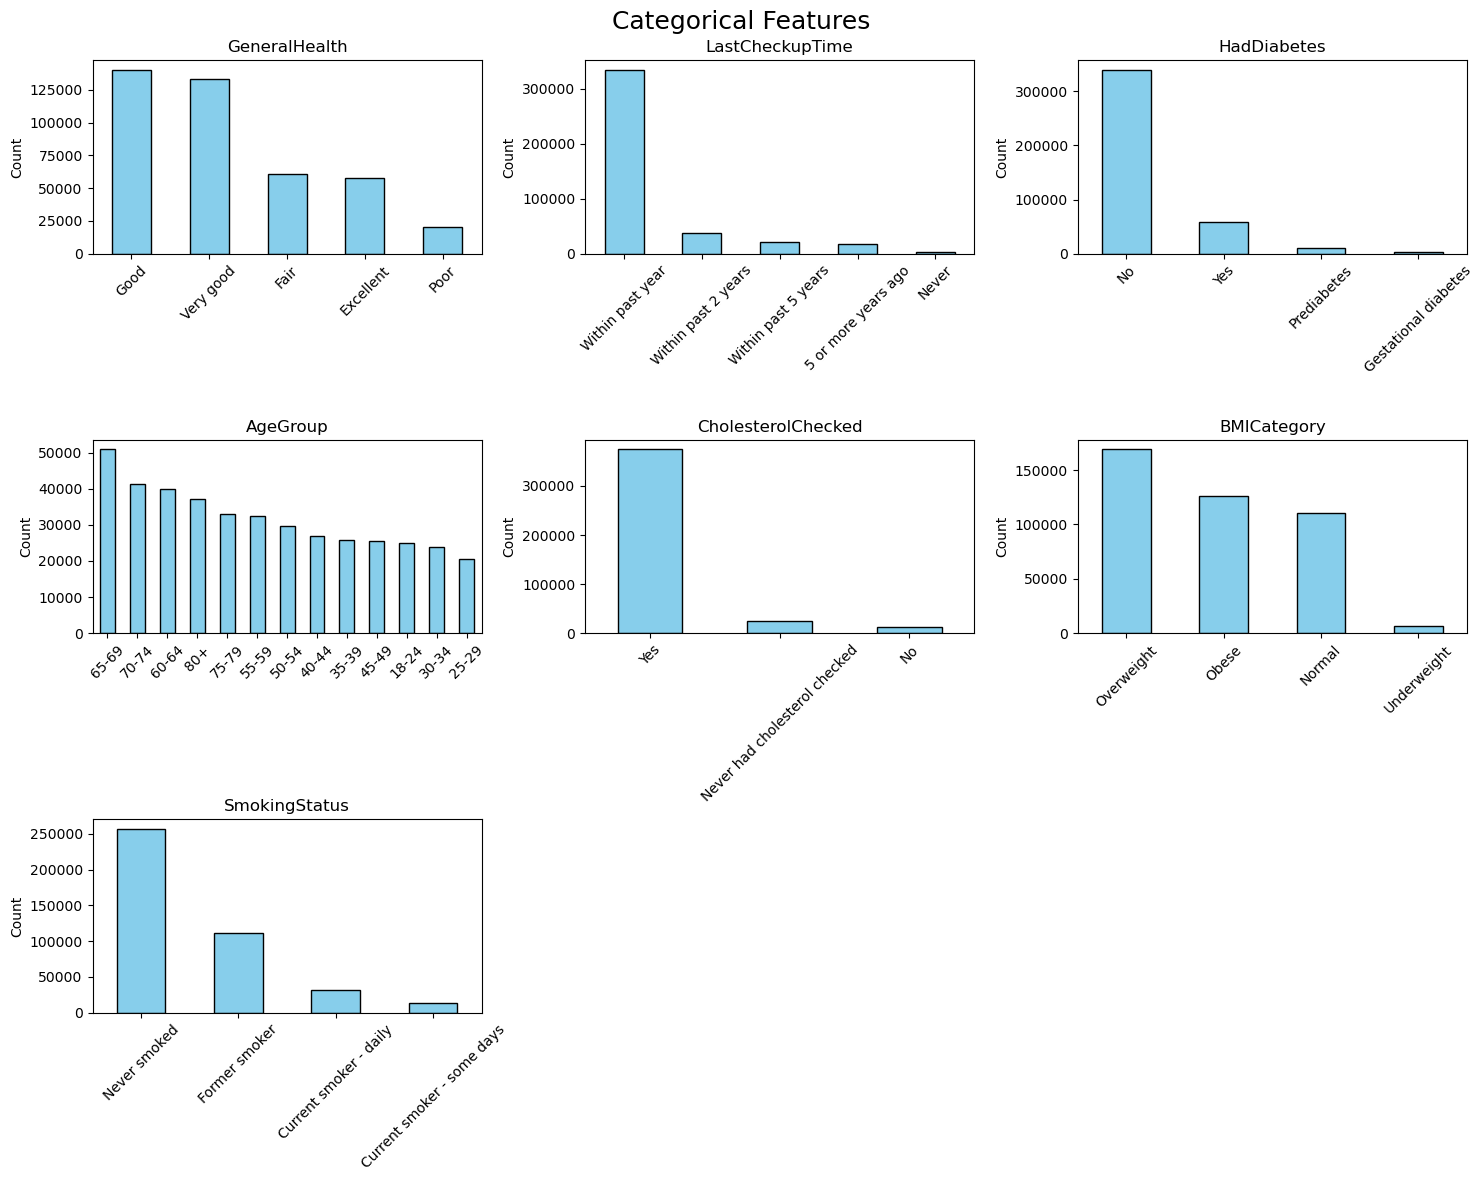

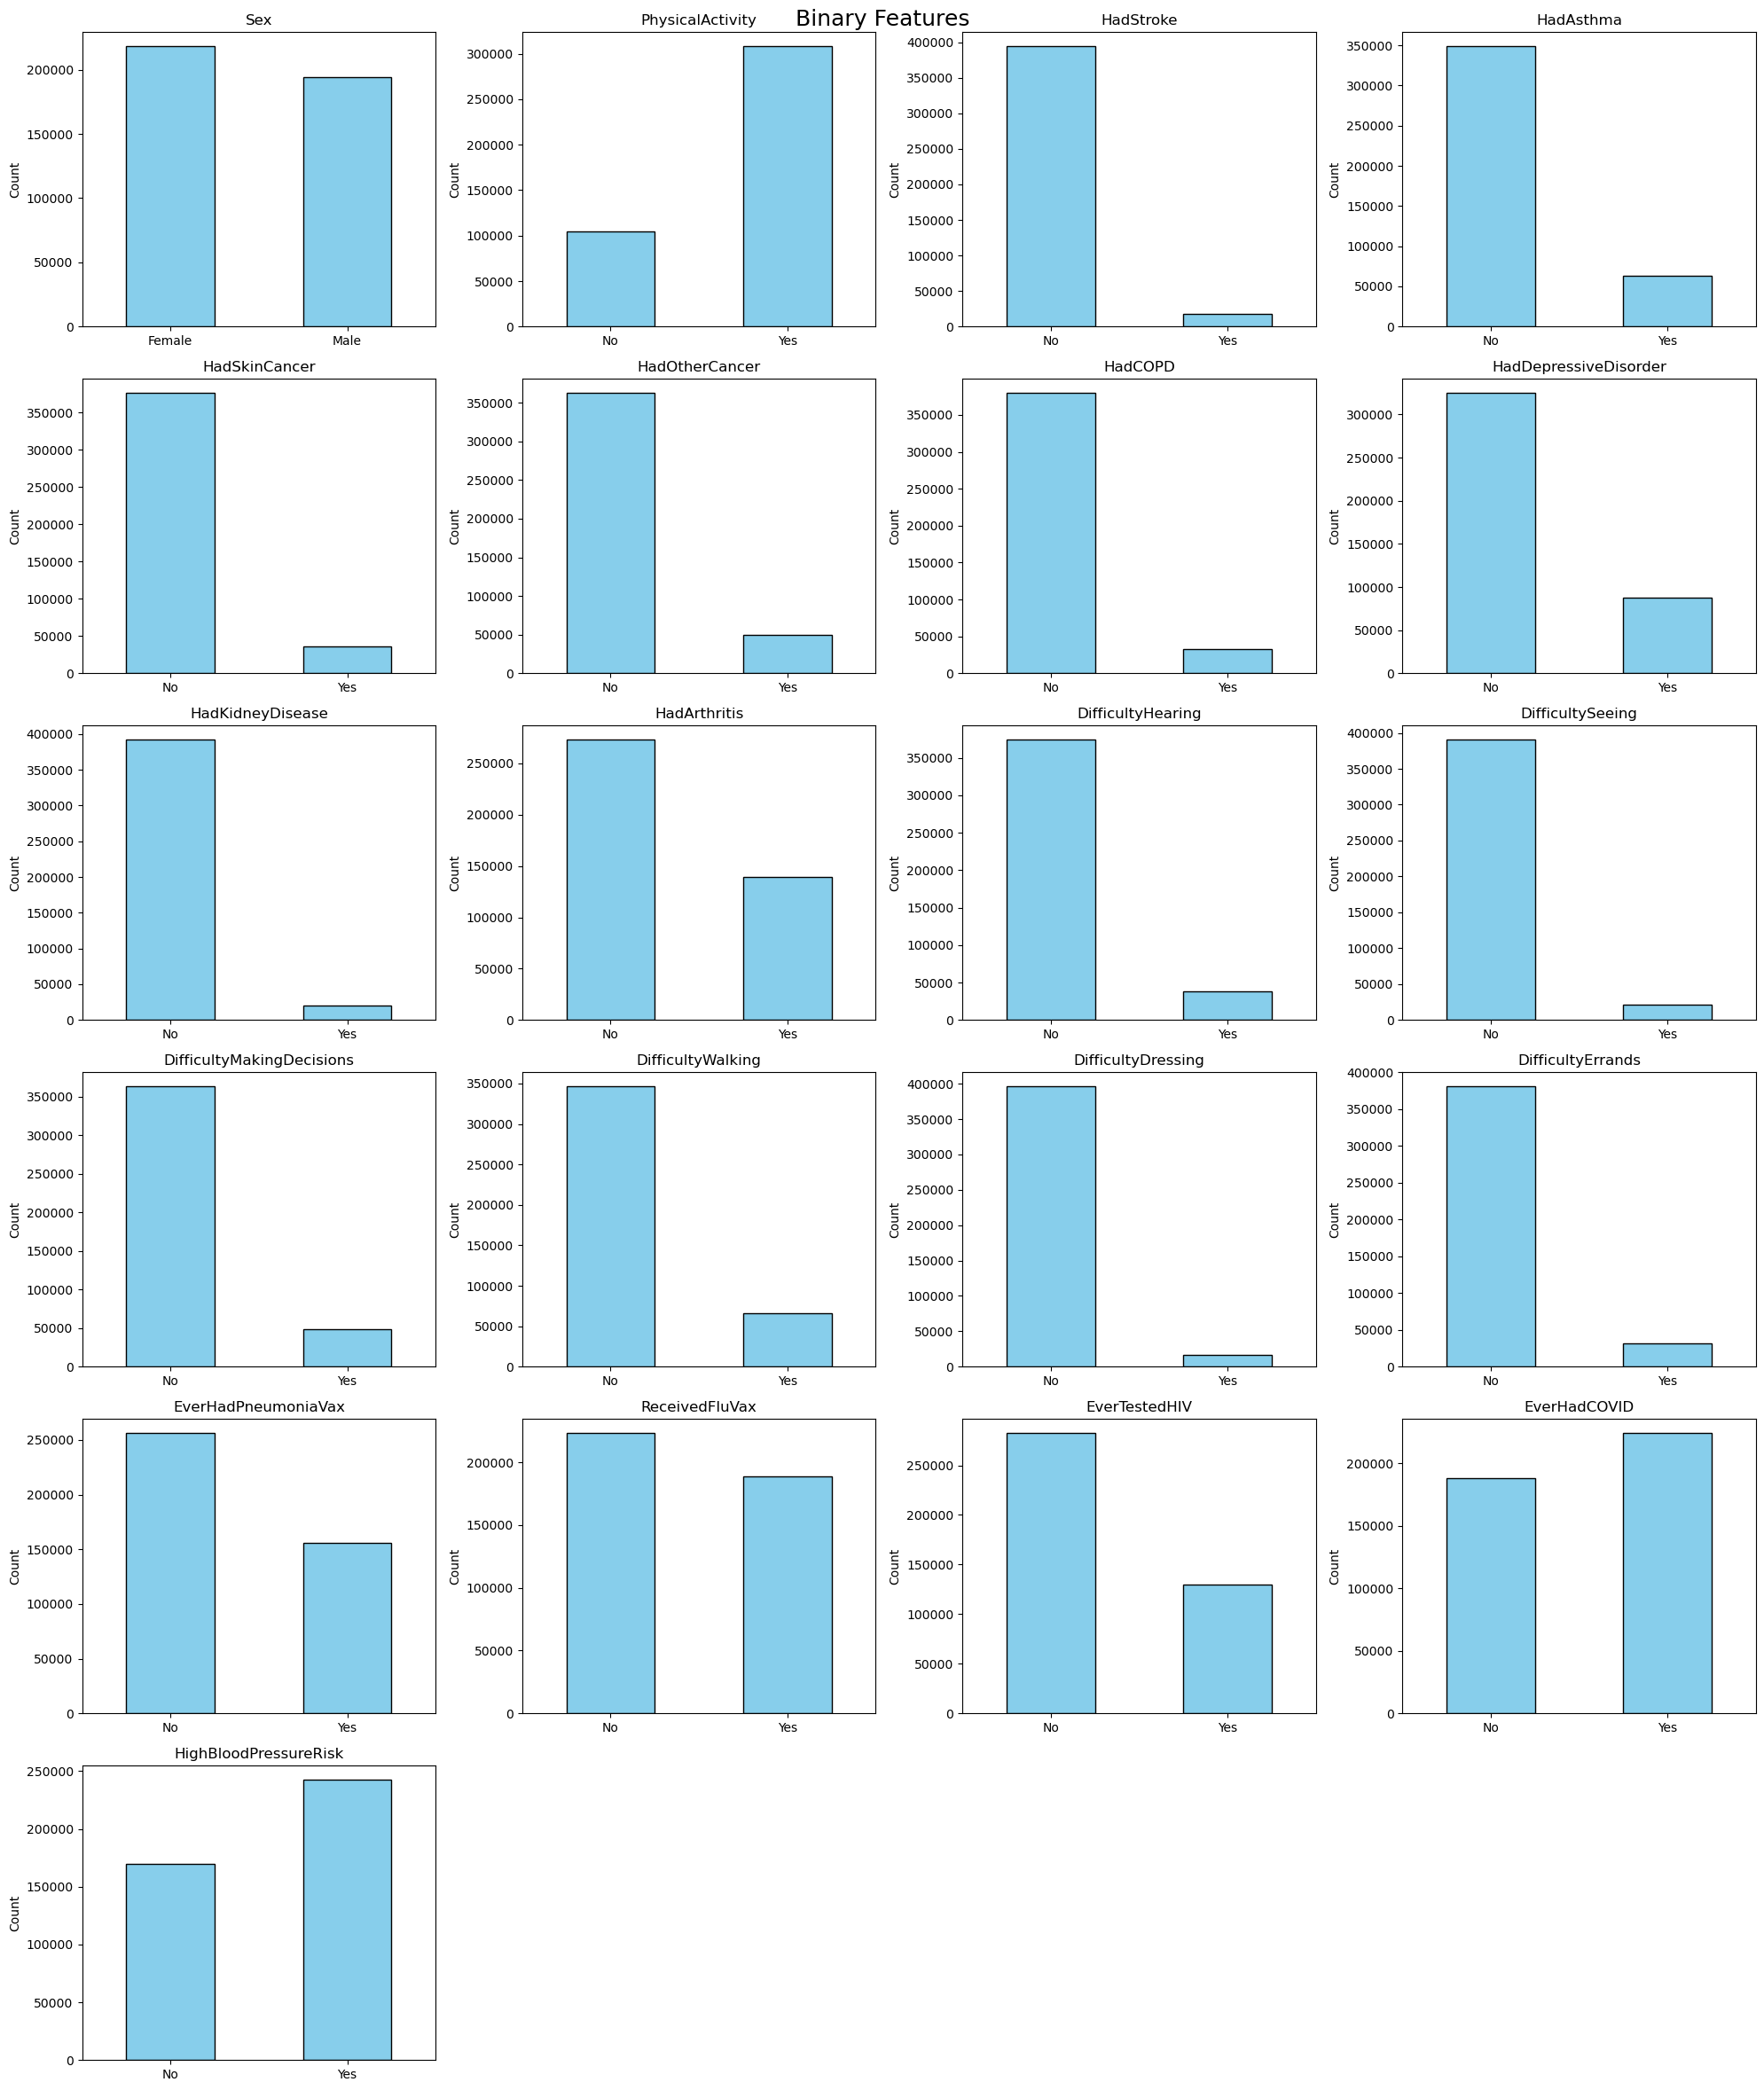

✅ All plots generated successfully.


In [24]:
df_plot = pd.concat(
    [X_train, X_val, X_test],
    axis=0,
    ignore_index=True
)

binary_cols = [
    col for col in df_plot.columns
    if df_plot[col].nunique(dropna=True) == 2
]


numerical_cols = df_plot.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_plot.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_cols = [col for col in numerical_cols if col not in binary_cols]
categorical_cols = [col for col in categorical_cols if col not in binary_cols]

print(f"Categorical Features: {len(categorical_cols)}")
print(f"Binary Features: {len(binary_cols)}")
print(f"Numerical Features: {len(numerical_cols)}")


if len(categorical_cols) > 0:

    n_cols = 3
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(5 * n_cols, 4 * n_rows)
    )

    axes = np.array(axes).flatten()

    for i, column in enumerate(categorical_cols):

        df_plot[column].value_counts(dropna=False).plot(
            kind='bar',
            ax=axes[i],
            color='skyblue',
            edgecolor='black'
        )

        axes[i].set_title(column, fontsize=12)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Categorical Features ", fontsize=18)
    plt.tight_layout()

    plt.savefig(
        "All_Imputed_Categorical.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()



if len(binary_cols) > 0:

    n_cols = 4
    n_rows = (len(binary_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(5 * n_cols, 4 * n_rows)
    )

    axes = np.array(axes).flatten()

    for i, column in enumerate(binary_cols):

        df_plot[column].value_counts(dropna=False).sort_index().plot(
            kind='bar',
            ax=axes[i],
            color='skyblue',
            edgecolor='black'
        )

        axes[i].set_title(column, fontsize=12)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis='x', rotation=0)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Binary Features", fontsize=18)
    plt.tight_layout()

    plt.savefig(
        "All_Imputed_Binary.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

print("✅ All plots generated successfully.")

# Data Encoding

In [34]:


binary_cols = [
    "PhysicalActivity",
    "HadHeartAttack",
    "HadStroke",
    "HadAsthma",
    "HadSkinCancer",
    "HadOtherCancer",
    "HadCOPD",
    "HadDepressiveDisorder",
    "HadKidneyDisease",
    "HadArthritis",
    "DifficultyHearing",
    "DifficultySeeing",
    "DifficultyMakingDecisions",
    "DifficultyWalking",
    "DifficultyDressing",
    "DifficultyErrands",
    "EverHadPneumoniaVax",
    "ReceivedFluVax",
    "EverTestedHIV",
    "EverHadCOVID",
    "HighBloodPressureRisk"
]


ordinal_cols = [
    "GeneralHealth",
    "AgeGroup",
    "LastCheckupTime",
    "CholesterolChecked"
]


ordinal_map = {

    "GeneralHealth": [
        "Poor",
        "Fair",
        "Good",
        "Very good",
        "Excellent"
    ],

    "AgeGroup": [
        "18-24",
        "25-29",
        "30-34",
        "35-39",
        "40-44",
        "45-49",
        "50-54",
        "55-59",
        "60-64",
        "65-69",
        "70-74",
        "75-79",
        "80+"
    ],

    "LastCheckupTime": [
        "Within past year",
        "Within past 2 years",
        "Within past 5 years",
        "5 or more years ago",
        "Never"
    ],

    "CholesterolChecked": [
        "Yes",
        "No",
        "Never had cholesterol checked"
    ]
}


nominal_cols = [
    "Sex",
    "SmokingStatus",
    "BMICategory",
    "HadDiabetes"
]


def binary_encode(data):

    data = data.copy()

    mapping = {
        "No":0,
        "Yes":1
    }

    for col in binary_cols:

        if col in data.columns:

            data[col] = (
                data[col]
                .astype(str)
                .str.strip()
                .map(mapping)
            )

    return data

ordinal_encoder = OrdinalEncoder(
    categories=[
        ordinal_map[col] for col in ordinal_cols
    ],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)


def fit_frequency_encoder(train):

    freq_maps={}

    for col in nominal_cols:

        if col in train.columns:

            freq_maps[col] = (
                train[col]
                .value_counts(normalize=True)
                .to_dict()
            )

    return freq_maps



def apply_frequency_encoder(data, freq_maps):

    data=data.copy()

    for col,mapping in freq_maps.items():

        data[col] = (
            data[col]
            .map(mapping)
            .fillna(0)
        )

    return data

def encode_dataset(X_train, X_val, X_test):


    X_train = binary_encode(X_train)
    X_val   = binary_encode(X_val)
    X_test  = binary_encode(X_test)


    X_train[ordinal_cols] = ordinal_encoder.fit_transform(
        X_train[ordinal_cols]
    )

    X_val[ordinal_cols] = ordinal_encoder.transform(
        X_val[ordinal_cols]
    )

    X_test[ordinal_cols] = ordinal_encoder.transform(
        X_test[ordinal_cols]
    )


    freq_maps = fit_frequency_encoder(
        X_train
    )


    X_train = apply_frequency_encoder(
        X_train,
        freq_maps
    )

    X_val = apply_frequency_encoder(
        X_val,
        freq_maps
    )

    X_test = apply_frequency_encoder(
        X_test,
        freq_maps
    )


    return X_train, X_val, X_test


X_train_encoded, X_val_encoded, X_test_encoded = encode_dataset(
    X_train,
    X_val,
    X_test
)

print("Train:", X_train_encoded.shape)
print("Validation:", X_val_encoded.shape)
print("Test:", X_test_encoded.shape)


print("\nRemaining object columns:")
print(
    X_train_encoded.select_dtypes(include="object").columns
)


print("\nMissing values:")
print(
    X_train_encoded.isna().sum().sum()
)


X_train_encoded.to_csv(
    "X_train_encoded.csv",
    index=False
)

X_val_encoded.to_csv(
    "X_val_encoded.csv",
    index=False
)

X_test_encoded.to_csv(

    "X_test_encoded.csv",
    index=False
)


print("✅ Encoding completed without leakage")

Train: (329944, 31)
Validation: (41243, 31)
Test: (41243, 31)

Remaining object columns:
Index([], dtype='object')

Missing values:
0
✅ Encoding completed without leakage


# Scaling

In [35]:

scaler = StandardScaler()


X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_encoded),
    columns=X_train_encoded.columns
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_encoded),
    columns=X_val_encoded.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_encoded),
    columns=X_test_encoded.columns
)


trained_scaled = X_train_scaled.copy()
trained_scaled["HadHeartAttack"] = y_train.values

validation_scaled = X_val_scaled.copy()
validation_scaled["HadHeartAttack"] = y_val.values

test_scaled = X_test_scaled.copy()
test_scaled["HadHeartAttack"] = y_test.values

trained_scaled.to_csv("trained_scaled.csv", index=False)
validation_scaled.to_csv("validation_scaled.csv", index=False)
test_scaled.to_csv("test_scaled.csv", index=False)

print("Saved:")
print("  trained_scaled.csv")
print("  validation_scaled.csv")
print("  test_scaled.csv")

Saved:
  trained_scaled.csv
  validation_scaled.csv
  test_scaled.csv


# Data Augmentation By Resampling 

In [37]:

mapping = {
    "No": 0,
    "Yes": 1
}

y_train = y_train.replace(mapping).astype(int)
y_val   = y_val.replace(mapping).astype(int)
y_test  = y_test.replace(mapping).astype(int)

print(y_train.value_counts())
print(y_train.dtype)

HadHeartAttack
0    311226
1     18718
Name: count, dtype: int64
int32


In [38]:

print("=" * 70)
print("APPLYING SMOTE TO TRAINING SET ONLY")
print("=" * 70)


print("\nOriginal Training Set")

print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"y_train        : {y_train.shape}")

train_distribution = (
    pd.Series(y_train, name="HadHeartAttack")
      .value_counts()
      .sort_index()
)

print("\nTraining Class Distribution")
print(train_distribution)

print("\nTraining Class Percentage (%)")
print(
    (
        train_distribution /
        train_distribution.sum() * 100
    ).round(2)
)


smote = SMOTE(
    sampling_strategy=1.0,
    random_state=42,
    k_neighbors=3
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

X_train_smote = pd.DataFrame(
    X_train_smote,
    columns=X_train_scaled.columns
)

y_train_smote = pd.Series(
    y_train_smote,
    name="HadHeartAttack"
)


print("\n")
print("=" * 70)
print("AFTER SMOTE")
print("=" * 70)

print(f"X_train_smote : {X_train_smote.shape}")
print(f"y_train_smote : {y_train_smote.shape}")

smote_distribution = (
    y_train_smote
    .value_counts()
    .sort_index()
)

print("\nTraining Class Distribution After SMOTE")
print(smote_distribution)

print("\nTraining Class Percentage (%)")

print(
    (
        smote_distribution /
        smote_distribution.sum() * 100
    ).round(2)
)

majority = smote_distribution.loc[0]
minority = smote_distribution.loc[1]

print("\nMinority / Majority Ratio")
print(f"{minority / majority:.2f}")


print("\n")
print("=" * 70)
print("VALIDATION AND TEST SETS (UNCHANGED)")
print("=" * 70)

print(f"Validation Features : {X_val_scaled.shape}")
print(f"Validation Target   : {y_val.shape}")

print(f"Test Features       : {X_test_scaled.shape}")
print(f"Test Target         : {y_test.shape}")

print("\nValidation Positive Fraction")
print(f"{y_val.mean():.2f}")

print("\nTest Positive Fraction")
print(f"{y_test.mean():.2f}")

train_smote = pd.concat(
    [
        X_train_smote.reset_index(drop=True),
        y_train_smote.reset_index(drop=True)
    ],
    axis=1
)

train_smote.to_csv(
    "train_scaled_smote.csv",
    index=False
)

print("\n")
print("=" * 70)
print("SMOTE TRAINING DATA SAVED")
print("=" * 70)

print(f"Filename : train_scaled_smote.csv")
print(f"Shape    : {train_smote.shape}")

print("\nFirst Five Rows")
print(train_smote.head())

print("\n")
print("=" * 70)
print("SMOTE APPLIED ONLY TO TRAINING DATA")
print("VALIDATION SET REMAINS ORIGINAL")
print("TEST SET REMAINS ORIGINAL")
print("=" * 70)

APPLYING SMOTE TO TRAINING SET ONLY

Original Training Set
X_train_scaled : (329944, 31)
y_train        : (329944,)

Training Class Distribution
HadHeartAttack
0    311226
1     18718
Name: count, dtype: int64

Training Class Percentage (%)
HadHeartAttack
0    94.33
1     5.67
Name: count, dtype: float64


AFTER SMOTE
X_train_smote : (622452, 31)
y_train_smote : (622452,)

Training Class Distribution After SMOTE
HadHeartAttack
0    311226
1    311226
Name: count, dtype: int64

Training Class Percentage (%)
HadHeartAttack
0    50.0
1    50.0
Name: count, dtype: float64

Minority / Majority Ratio
1.00


VALIDATION AND TEST SETS (UNCHANGED)
Validation Features : (41243, 31)
Validation Target   : (41243,)
Test Features       : (41243, 31)
Test Target         : (41243,)

Validation Positive Fraction
0.06

Test Positive Fraction
0.06


SMOTE TRAINING DATA SAVED
Filename : train_scaled_smote.csv
Shape    : (622452, 32)

First Five Rows
        Sex  GeneralHealth  PhysicalHealthDays  MentalHea

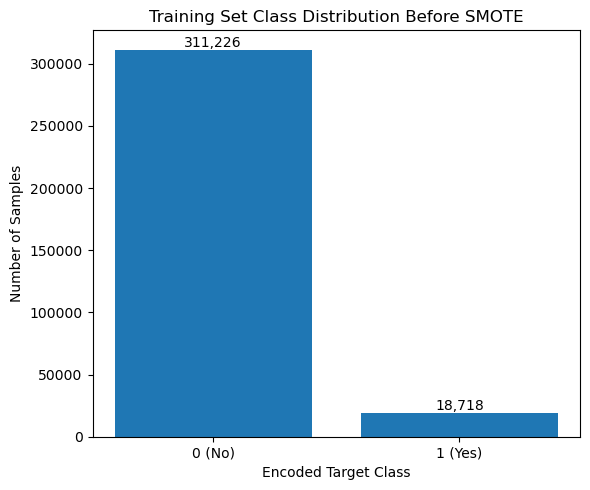

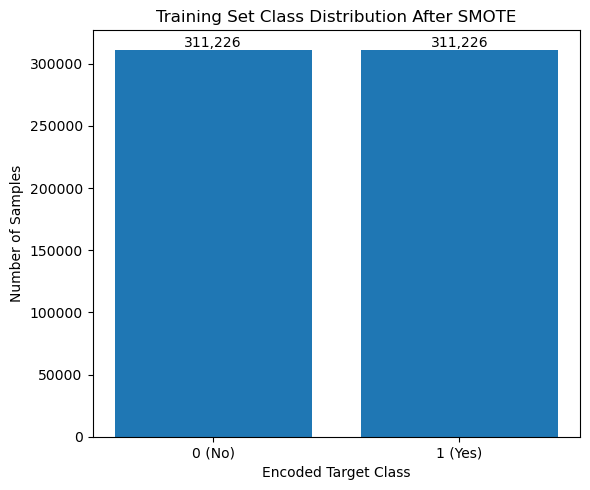


Before SMOTE
HadHeartAttack
0    311226
1     18718
Name: count, dtype: int64

After SMOTE
HadHeartAttack
0    311226
1    311226
Name: count, dtype: int64


In [39]:
before_counts = y_train.value_counts().sort_index()
after_counts = y_train_smote.value_counts().sort_index()
plt.figure(figsize=(6,5))
bars = plt.bar(before_counts.index.astype(str), before_counts.values)

plt.title("Training Set Class Distribution Before SMOTE")
plt.xlabel("Encoded Target Class")
plt.ylabel("Number of Samples")

plt.xticks([0,1], ["0 (No)", "1 (Yes)"])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("before_smote.png", dpi=300)
plt.show()


plt.figure(figsize=(6,5))

bars = plt.bar(after_counts.index.astype(str), after_counts.values)

plt.title("Training Set Class Distribution After SMOTE")
plt.xlabel("Encoded Target Class")
plt.ylabel("Number of Samples")

plt.xticks([0,1], ["0 (No)", "1 (Yes)"])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("after_smote.png", dpi=300)
plt.show()

print("\nBefore SMOTE")
print(before_counts)

print("\nAfter SMOTE")
print(after_counts)